Loading metadata...
Original dataset: 5224 samples
Upsampled dataset: 8176 samples


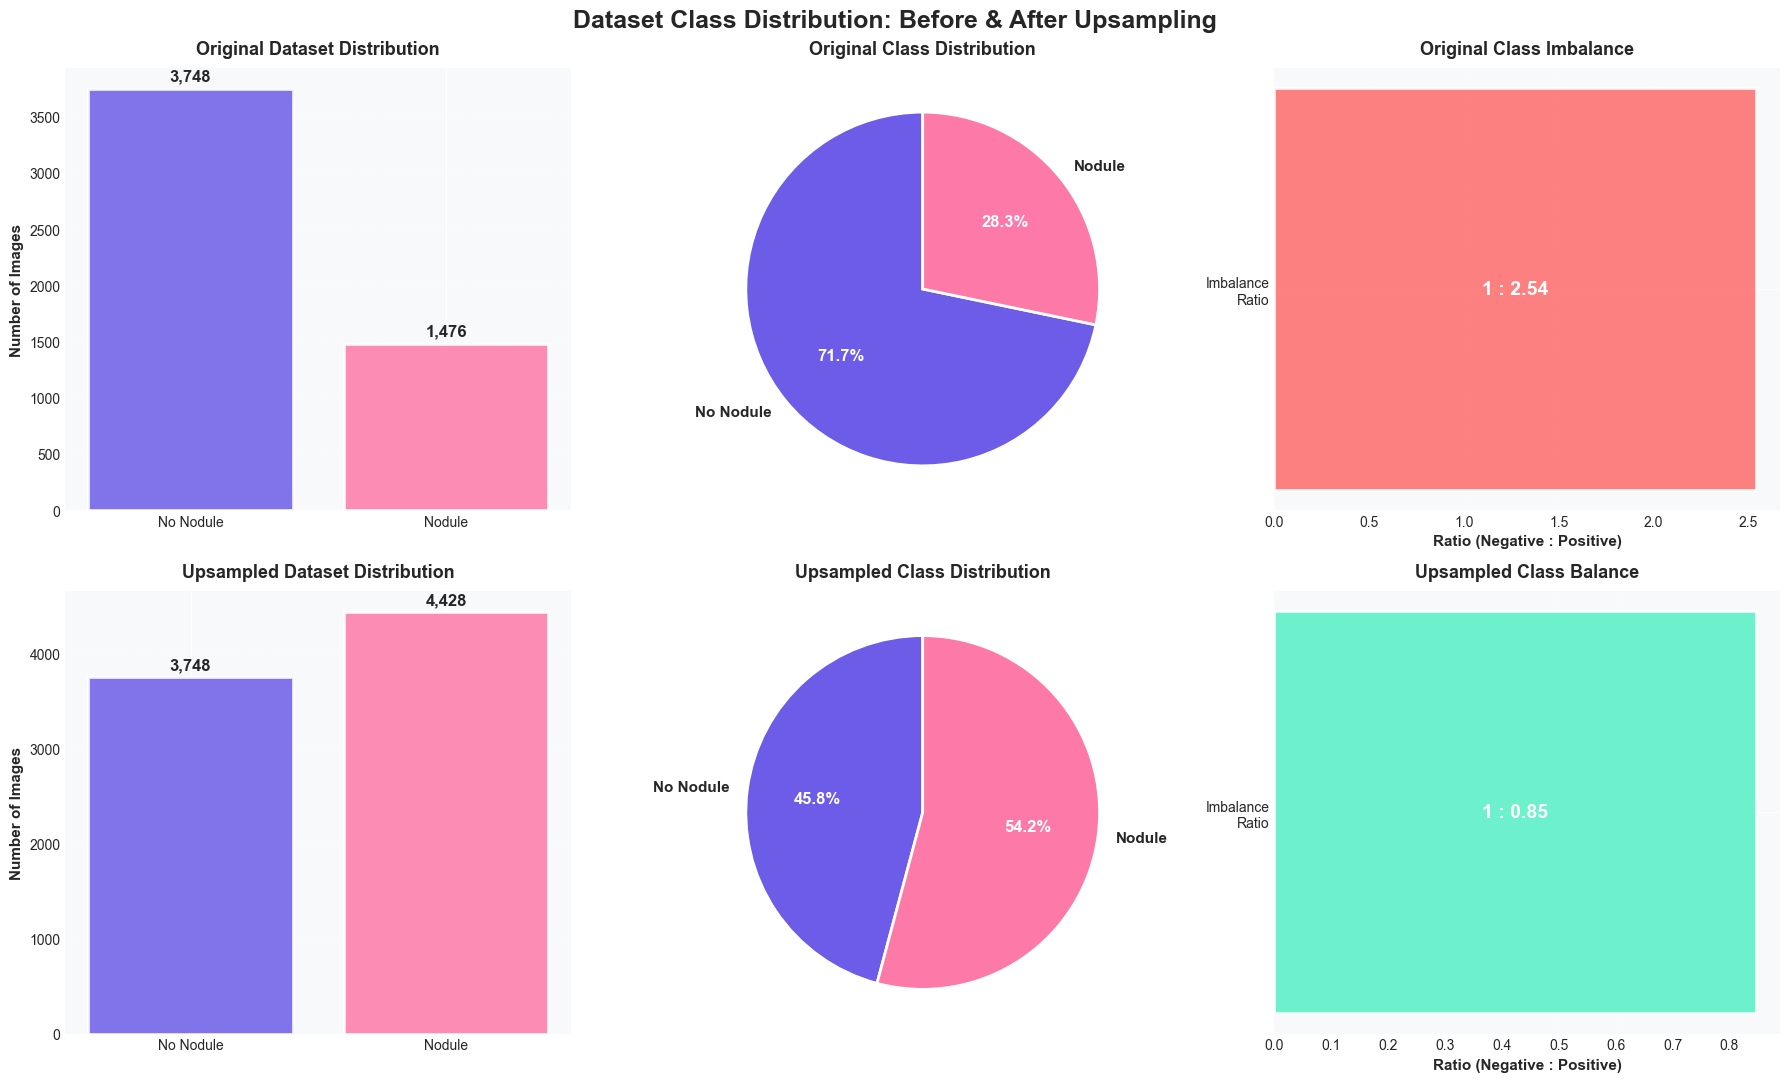

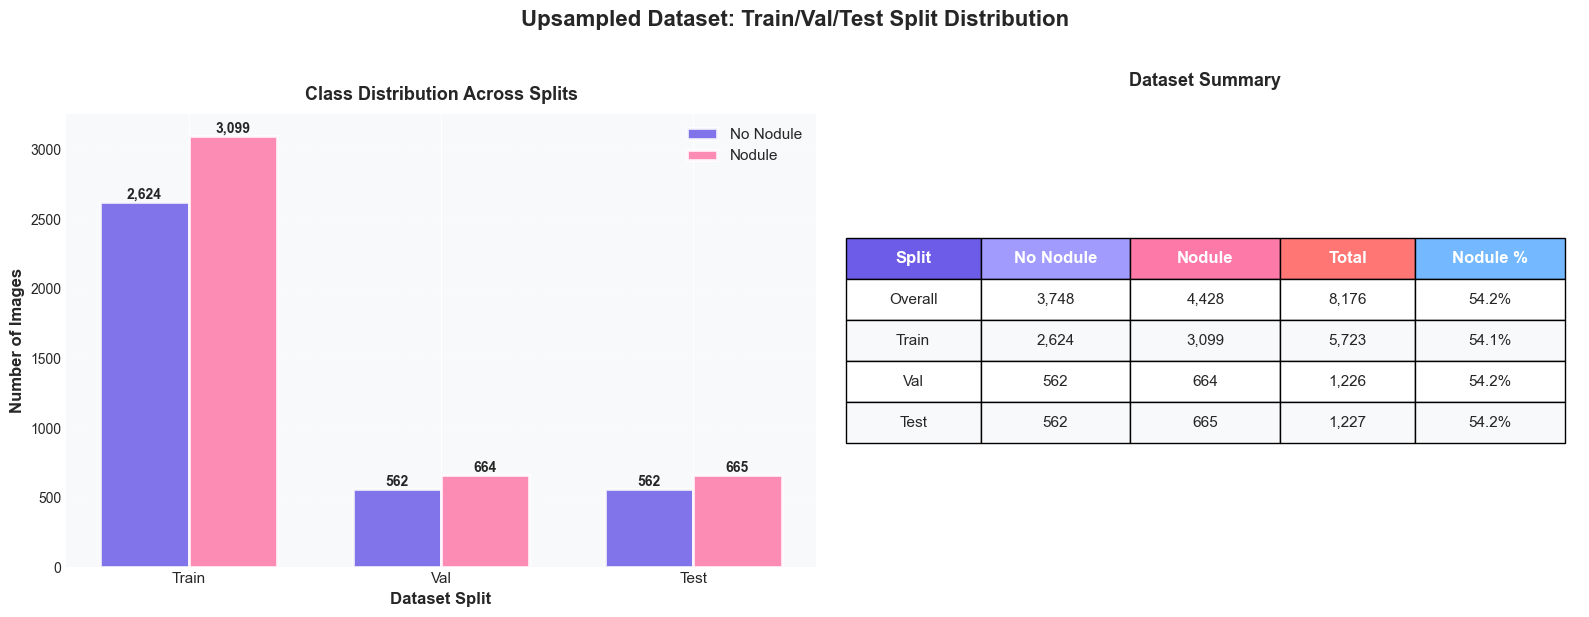


📊 BEFORE UPSAMPLING
Total images: 5,224
No Nodule (0): 3,748 (71.7%)
Nodule (1): 1,476 (28.3%)
Imbalance ratio: 1 : 2.54

📊 AFTER UPSAMPLING
Total images: 8,176
No Nodule (0): 3,748 (45.8%)
Nodule (1): 4,428 (54.2%)
Imbalance ratio: 1 : 0.85
Improvement: 200.0% more balanced

📊 SPLIT DISTRIBUTION (70/15/15)

Train:
  Total: 5,723
  No Nodule: 2,624 (45.9%)
  Nodule: 3,099 (54.1%)

Val:
  Total: 1,226
  No Nodule: 562 (45.8%)
  Nodule: 664 (54.2%)

Test:
  Total: 1,227
  No Nodule: 562 (45.8%)
  Nodule: 665 (54.2%)

✓ Visualizations saved:
  - before_after_upsampling.png
  - split_distribution.png


In [1]:
# Dataset Class Distribution Visualization
# Visualize class distribution before and after upsampling

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import os

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

# %% Load Data
original_csv_path = "./dataset_nodule21/cxr_images/proccessed_data/metadata.csv"
upsampled_csv_path = "./dataset_nodule21/cxr_images/proccessed_data/metadata_upsampled.csv"

print("Loading metadata...")
df_original = pd.read_csv(original_csv_path)
df_upsampled = pd.read_csv(upsampled_csv_path)

print(f"Original dataset: {len(df_original)} samples")
print(f"Upsampled dataset: {len(df_upsampled)} samples")

# Pretty colors - Modern gradient palette
colors_negative = '#6C5CE7'  # Soft purple
colors_positive = '#FD79A8'   # Soft pink
colors_gradient = ['#A29BFE', '#FD79A8']  # Light purple to pink

# %% Figure 1: Before vs After Upsampling
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Dataset Class Distribution: Before & After Upsampling', 
             fontsize=18, fontweight='bold', y=0.98)

# BEFORE UPSAMPLING
# 1. Bar chart
original_counts = df_original['label'].value_counts().sort_index()
bars = axes[0, 0].bar(['No Nodule', 'Nodule'], original_counts.values, 
                      color=[colors_negative, colors_positive], alpha=0.85, 
                      edgecolor='white', linewidth=2)
axes[0, 0].set_ylabel('Number of Images', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Original Dataset Distribution', fontsize=13, fontweight='bold', pad=10)
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0, 0].set_facecolor('#F8F9FA')
for i, (bar, v) in enumerate(zip(bars, original_counts.values)):
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 50,
                    f'{v:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# 2. Pie chart
wedges, texts, autotexts = axes[0, 1].pie(original_counts.values, 
                                           labels=['No Nodule', 'Nodule'], 
                                           autopct='%1.1f%%',
                                           colors=[colors_negative, colors_positive],
                                           startangle=90,
                                           textprops={'fontsize': 11, 'weight': 'bold'},
                                           wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
axes[0, 1].set_title('Original Class Distribution', fontsize=13, fontweight='bold', pad=10)

# 3. Imbalance visualization
imbalance_ratio = original_counts[0] / original_counts[1]
axes[0, 2].barh(['Imbalance\nRatio'], [imbalance_ratio], 
                color='#FF6B6B', alpha=0.85, edgecolor='white', linewidth=2)
axes[0, 2].set_xlabel('Ratio (Negative : Positive)', fontsize=11, fontweight='bold')
axes[0, 2].set_title('Original Class Imbalance', fontsize=13, fontweight='bold', pad=10)
axes[0, 2].text(imbalance_ratio/2, 0, f'1 : {imbalance_ratio:.2f}', 
                ha='center', va='center', fontsize=14, fontweight='bold', color='white')
axes[0, 2].set_facecolor('#F8F9FA')
axes[0, 2].grid(axis='x', alpha=0.3, linestyle='--')

# AFTER UPSAMPLING
# 4. Bar chart
upsampled_counts = df_upsampled['label'].value_counts().sort_index()
bars = axes[1, 0].bar(['No Nodule', 'Nodule'], upsampled_counts.values,
                      color=[colors_negative, colors_positive], alpha=0.85,
                      edgecolor='white', linewidth=2)
axes[1, 0].set_ylabel('Number of Images', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Upsampled Dataset Distribution', fontsize=13, fontweight='bold', pad=10)
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
axes[1, 0].set_facecolor('#F8F9FA')
for i, (bar, v) in enumerate(zip(bars, upsampled_counts.values)):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 50,
                    f'{v:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# 5. Pie chart
wedges, texts, autotexts = axes[1, 1].pie(upsampled_counts.values,
                                           labels=['No Nodule', 'Nodule'],
                                           autopct='%1.1f%%',
                                           colors=[colors_negative, colors_positive],
                                           startangle=90,
                                           textprops={'fontsize': 11, 'weight': 'bold'},
                                           wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
axes[1, 1].set_title('Upsampled Class Distribution', fontsize=13, fontweight='bold', pad=10)

# 6. Imbalance visualization
new_imbalance_ratio = upsampled_counts[0] / upsampled_counts[1]
axes[1, 2].barh(['Imbalance\nRatio'], [new_imbalance_ratio],
                color='#55EFC4', alpha=0.85, edgecolor='white', linewidth=2)
axes[1, 2].set_xlabel('Ratio (Negative : Positive)', fontsize=11, fontweight='bold')
axes[1, 2].set_title('Upsampled Class Balance', fontsize=13, fontweight='bold', pad=10)
axes[1, 2].text(new_imbalance_ratio/2, 0, f'1 : {new_imbalance_ratio:.2f}',
                ha='center', va='center', fontsize=14, fontweight='bold', color='white')
axes[1, 2].set_facecolor('#F8F9FA')
axes[1, 2].grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('before_after_upsampling.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# %% Figure 2: Split Distribution (After Upsampling)
train_df, temp_df = train_test_split(df_upsampled, test_size=0.3, stratify=df_upsampled['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Upsampled Dataset: Train/Val/Test Split Distribution', 
             fontsize=16, fontweight='bold', y=1.02)

# 1. Grouped bar chart
splits_data = {
    'Train': train_df['label'].value_counts().sort_index(),
    'Val': val_df['label'].value_counts().sort_index(),
    'Test': test_df['label'].value_counts().sort_index()
}

x = np.arange(len(splits_data))
width = 0.35
bars1 = axes[0].bar(x - width/2, [splits_data[k][0] for k in splits_data.keys()],
                    width, label='No Nodule', color=colors_negative, alpha=0.85,
                    edgecolor='white', linewidth=2)
bars2 = axes[0].bar(x + width/2, [splits_data[k][1] for k in splits_data.keys()],
                    width, label='Nodule', color=colors_positive, alpha=0.85,
                    edgecolor='white', linewidth=2)

axes[0].set_xlabel('Dataset Split', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Images', fontsize=12, fontweight='bold')
axes[0].set_title('Class Distribution Across Splits', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xticks(x)
axes[0].set_xticklabels(splits_data.keys(), fontsize=11)
axes[0].legend(fontsize=11, framealpha=0.9)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_facecolor('#F8F9FA')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Summary table
summary_data = []
for split_name, split_df in [('Overall', df_upsampled), ('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    no_nodule = (split_df['label'] == 0).sum()
    nodule = (split_df['label'] == 1).sum()
    total = len(split_df)
    summary_data.append([split_name, f'{no_nodule:,}', f'{nodule:,}', f'{total:,}',
                        f"{nodule/total*100:.1f}%"])

axes[1].axis('tight')
axes[1].axis('off')
table = axes[1].table(cellText=summary_data,
                      colLabels=['Split', 'No Nodule', 'Nodule', 'Total', 'Nodule %'],
                      cellLoc='center',
                      loc='center',
                      colWidths=[0.18, 0.2, 0.2, 0.18, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header with gradient
header_colors = ['#6C5CE7', '#A29BFE', '#FD79A8', '#FF7675', '#74B9FF']
for i in range(5):
    table[(0, i)].set_facecolor(header_colors[i])
    table[(0, i)].set_text_props(weight='bold', color='white', fontsize=12)

# Alternate row colors
for i in range(1, len(summary_data) + 1):
    for j in range(5):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#F8F9FA')
        else:
            table[(i, j)].set_facecolor('white')
        table[(i, j)].set_text_props(fontsize=11)

axes[1].set_title('Dataset Summary', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('split_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# %% Print Statistics
print("\n" + "="*70)
print("📊 BEFORE UPSAMPLING")
print("="*70)
print(f"Total images: {len(df_original):,}")
print(f"No Nodule (0): {original_counts[0]:,} ({original_counts[0]/len(df_original)*100:.1f}%)")
print(f"Nodule (1): {original_counts[1]:,} ({original_counts[1]/len(df_original)*100:.1f}%)")
print(f"Imbalance ratio: 1 : {original_counts[0]/original_counts[1]:.2f}")

print("\n" + "="*70)
print("📊 AFTER UPSAMPLING")
print("="*70)
print(f"Total images: {len(df_upsampled):,}")
print(f"No Nodule (0): {upsampled_counts[0]:,} ({upsampled_counts[0]/len(df_upsampled)*100:.1f}%)")
print(f"Nodule (1): {upsampled_counts[1]:,} ({upsampled_counts[1]/len(df_upsampled)*100:.1f}%)")
print(f"Imbalance ratio: 1 : {upsampled_counts[0]/upsampled_counts[1]:.2f}")
print(f"Improvement: {((original_counts[0]/original_counts[1]) / (upsampled_counts[0]/upsampled_counts[1]) - 1) * 100:.1f}% more balanced")

print("\n" + "="*70)
print("📊 SPLIT DISTRIBUTION (70/15/15)")
print("="*70)
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    counts = split_df['label'].value_counts().sort_index()
    print(f"\n{split_name}:")
    print(f"  Total: {len(split_df):,}")
    print(f"  No Nodule: {counts[0]:,} ({counts[0]/len(split_df)*100:.1f}%)")
    print(f"  Nodule: {counts[1]:,} ({counts[1]/len(split_df)*100:.1f}%)")

print("\n✓ Visualizations saved:")
print("  - before_after_upsampling.png")
print("  - split_distribution.png")
print("="*70)